In [1]:
import cv2
import cv2.aruco as aruco

In [2]:
width = 4
height = 5
square_length = 0.05
marker_length = 0.0375
aruco_dict = aruco.DICT_4X4_1000
aruco_id_offset = 0
dictionary = aruco.getPredefinedDictionary(aruco_dict)

board = aruco.CharucoBoard((width, height), square_length, marker_length, dictionary)



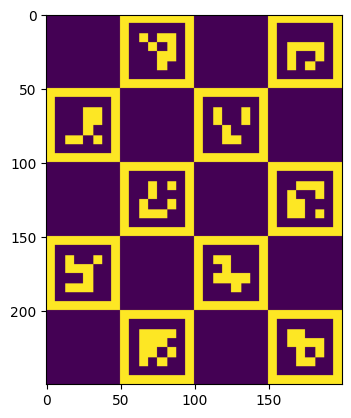

In [5]:
main_img = board.generateImage((int(width*square_length*1000), int(height*square_length*1000)))
import matplotlib.pyplot as plt
plt.imshow(main_img)
plt.show()


In [24]:
corners3d = board.getChessboardCorners()
corners3d

array([[0.05, 0.05, 0.  ],
       [0.1 , 0.05, 0.  ],
       [0.15, 0.05, 0.  ],
       [0.05, 0.1 , 0.  ],
       [0.1 , 0.1 , 0.  ],
       [0.15, 0.1 , 0.  ],
       [0.05, 0.15, 0.  ],
       [0.1 , 0.15, 0.  ],
       [0.15, 0.15, 0.  ],
       [0.05, 0.2 , 0.  ],
       [0.1 , 0.2 , 0.  ],
       [0.15, 0.2 , 0.  ]], dtype=float32)

In [27]:
import numpy as np
# convert to numpy array and flip y axis
corners3d = np.array(corners3d)
corners3d[:, 1] = -corners3d[:, 1]
corners3d


array([[ 0.05, -0.05,  0.  ],
       [ 0.1 , -0.05,  0.  ],
       [ 0.15, -0.05,  0.  ],
       [ 0.05, -0.1 ,  0.  ],
       [ 0.1 , -0.1 ,  0.  ],
       [ 0.15, -0.1 ,  0.  ],
       [ 0.05, -0.15,  0.  ],
       [ 0.1 , -0.15,  0.  ],
       [ 0.15, -0.15,  0.  ],
       [ 0.05, -0.2 ,  0.  ],
       [ 0.1 , -0.2 ,  0.  ],
       [ 0.15, -0.2 ,  0.  ]], dtype=float32)

In [7]:
img = cv2.imread("/home/david/projects/calib-4x5/135_bottom_right/image1_Color.png")

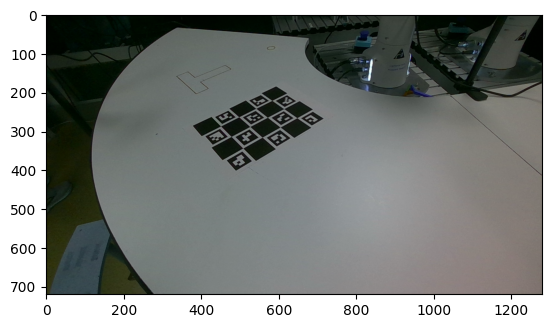

In [8]:
import matplotlib.pyplot as plt
plt.imshow(img)
plt.show()

In [9]:
from waynon.detectors.charuco_processor import detect_charuco_board
result = detect_charuco_board(img, board)
assert result is not None

corner_ids, corner_pixels, marker_ids, marker_pixels = result





In [10]:
corner_ids

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11], dtype=int32)

In [13]:
corner_pixels

array([[584.2039 , 223.30666],
       [614.99536, 244.69835],
       [648.7299 , 267.95337],
       [542.8281 , 243.77592],
       [572.63873, 266.75082],
       [605.48804, 291.97153],
       [498.85504, 265.6357 ],
       [527.2697 , 290.48517],
       [559.0705 , 317.98428],
       [451.8777 , 289.26944],
       [478.9827 , 316.0276 ],
       [509.2585 , 345.9165 ]], dtype=float32)

In [15]:
corner_ids.shape

(12, 1)

In [20]:
corner

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11], dtype=int32)

In [16]:
marker_ids.shape

(10, 1)

In [17]:
marker_pixels.shape

(10, 1, 4, 2)

In [ ]:
marker_pixels.shape

In [12]:
corner_pixels[:, 0, :].shape

(12, 2)

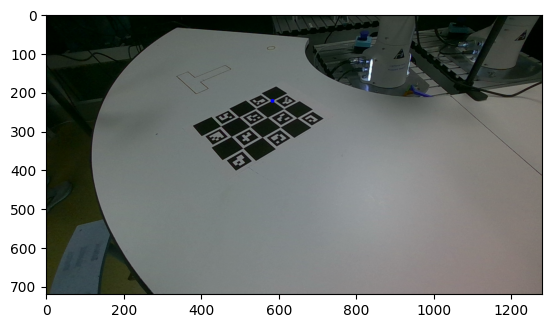

In [23]:
# render corner pixels on a copy of the img
img_copy = img.copy()
for i, (x, y) in enumerate(corner_pixels[0:1]):
    cv2.circle(img_copy, (int(x), int(y)), 5, (0, 0, 255), -1)

plt.imshow(img_copy)
plt.show()
